# 00 — Preprocess: GPS telemetry → labeled trip sequences

Turns the raw NetMob 2026 data into the model-ready cache used by the
autoencoder notebooks:

* **GTFS index** — shape polylines (local meters), stop distances along each
  shape, scheduled stop times per trip/direction/snapshot.
* **Trip instances** — one day of GPS at a time: deadheading dropped,
  segmented by `(tripId, vehicle)` with gap splitting, map-matched onto the
  GTFS shape, stop arrivals interpolated, **delay label** = median stop
  delay ≥ 5 min vs the schedule.
* **Sequences** — 1-minute bins, `T_MAX=64`, 12 label-free features per bin
  → `cache/sequences.npz` + `cache/trips_meta.parquet`.

All heavy lifting lives in `netmob_prep.py`; this notebook drives it and
verifies every stage.

In [1]:
import os
import pickle
import time

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

import netmob_prep as prep

pd.set_option("display.width", 160)
print("features:", prep.FEATURE_COLS)
print("delay threshold (s):", prep.DELAY_THRESHOLD_SEC)

features: ['speed_mps', 'accel', 'heading_change', 'progress_frac', 'progress_rate', 'cross_track_m', 'dwell_frac', 'tod_sin', 'tod_cos', 'is_weekend', 'rain_mm', 'headway_min']
delay threshold (s): 300


## 1. GTFS index (cached)

In [2]:
os.makedirs(prep.CACHE_DIR, exist_ok=True)
gtfs_pkl = os.path.join(prep.CACHE_DIR, "gtfs_index.pkl")
if os.path.exists(gtfs_pkl):
    with open(gtfs_pkl, "rb") as f:
        gtfs_index = pickle.load(f)
    print(f"loaded cached GTFS index: {len(gtfs_index)} trip keys")
else:
    t0 = time.time()
    gtfs_index = prep.build_gtfs_index()
    with open(gtfs_pkl, "wb") as f:
        pickle.dump(gtfs_index, f)
    print(f"built in {time.time()-t0:.0f}s")

rain_utc = prep.load_rain_by_utc_hour()
print(f"weather: {len(rain_utc)} hourly readings, "
      f"total rain {rain_utc.sum():.1f} mm, max {rain_utc.max():.1f} mm/h")

  TransNit_20260320: 4743 trips indexed


  TransOceanico_20260315: 7551 trips indexed


  TransOceanico_20260329: 7543 trips indexed
  total distinct trip keys: 8598
built in 54s
weather: 744 hourly readings, total rain 75.6 mm, max 11.8 mm/h


## 2. Process all days → cache

In [3]:
dates = prep.mobility_dates()
print(len(dates), "mobility days:", dates[0], "…", dates[-1])
t0 = time.time()
meta, counters = prep.build_dataset(dates, gtfs_index, rain_utc)
print(f"\ntotal preprocessing time: {(time.time()-t0)/60:.1f} min")

19 mobility days: 2026-03-11 … 2026-03-31


  2026-03-11: kept  1454 instances (raw rows 950,855)


  2026-03-12: kept  1419 instances (raw rows 985,831)


  2026-03-13: kept  1584 instances (raw rows 1,053,712)


  2026-03-14: kept  1401 instances (raw rows 774,648)


...

  2026-03-28: kept   449 instances (raw rows 328,626)


  2026-03-29: kept   984 instances (raw rows 504,273)


  2026-03-30: kept  1204 instances (raw rows 847,024)


  2026-03-31: kept  1153 instances (raw rows 895,242)



  dataset: X (22605, 64, 12), positives 20.9%, saved to /home/matt/prog/faculdade/ml/code/cache

total preprocessing time: 2.9 min


## 3. Verification — discard accounting & join quality

In [4]:
print("── per-day counters ──")
cols = ["raw_rows", "instances_raw", "no_gtfs", "too_few_points",
        "bad_duration", "offroute_discard", "low_stop_coverage",
        "sched_mismatch", "midnight_flips", "kept"]
print(counters[cols].to_string())
tot = counters.sum()
print("\nGTFS join failure rate:",
      f"{tot['no_gtfs'] / max(1, tot['instances_raw']):.2%}  (target < 1%)")
print("kept overall:", f"{tot['kept']:,} / {tot['instances_raw']:,} raw instances")

── per-day counters ──
            raw_rows  instances_raw  no_gtfs  too_few_points  bad_duration  offroute_discard  low_stop_coverage  sched_mismatch  midnight_flips  kept
date                                                                                                                                                 
2026-03-11    950855           2810        0               5           130               148                586             203              75  1454
2026-03-12    985831           2927        0               6           115               151                602             303              73  1419
2026-03-13   1053712           2806        0               7           127               169                400             231              41  1584
2026-03-14    774648           2111        0               5            46                98                369              41              63  1401
2026-03-15    481931           1387        0               5            46   

In [5]:
assert tot["no_gtfs"] / max(1, tot["instances_raw"]) < 0.01, "GTFS join degraded"
agree = (meta["direction"] == meta["gtfs_direction"]).mean()
print(f"mobility vs GTFS direction agreement: {agree:.1%}")
assert agree > 0.95

mobility vs GTFS direction agreement: 100.0%


## 4. Verification — delay distribution & label balance

The fleet-wide median stop delay must be centered near zero — a global
shift would indicate a timezone or service-day bug, not real lateness.

count    22605.0
mean      -107.5
std       1155.2
min      -7191.5
25%       -166.5
50%         36.5
75%        242.7
max       7175.8
Name: median_delay_sec, dtype: float64

label balance (delayed): 20.9%


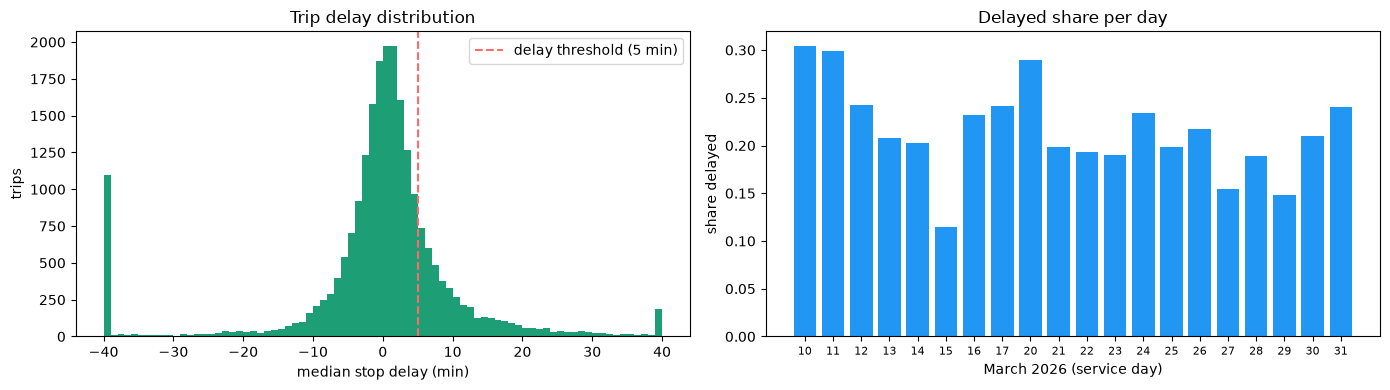

In [6]:
d = meta["median_delay_sec"]
print(d.describe().round(1))
print("\nlabel balance (delayed):", f"{meta['delayed'].mean():.1%}")
assert 0.10 <= meta["delayed"].mean() <= 0.45, "label balance outside sanity gate"
assert abs(d.median()) < 300, "fleet median delay far from 0 — check time handling"

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(d.clip(-2400, 2400) / 60, bins=80, color="#1D9E75")
axes[0].axvline(prep.DELAY_THRESHOLD_SEC / 60, color="#FF6B6B", ls="--",
                label="delay threshold (5 min)")
axes[0].set_xlabel("median stop delay (min)"); axes[0].set_ylabel("trips")
axes[0].set_title("Trip delay distribution"); axes[0].legend()
by_day = meta.groupby("service_date")["delayed"].agg(["mean", "size"])
axes[1].bar(range(len(by_day)), by_day["mean"], color="#2196F3")
axes[1].set_xticks(range(len(by_day)))
axes[1].set_xticklabels([s[8:] for s in by_day.index], rotation=0, fontsize=8)
axes[1].set_xlabel("March 2026 (service day)"); axes[1].set_ylabel("share delayed")
axes[1].set_title("Delayed share per day")
plt.tight_layout(); plt.savefig(os.path.join(prep.CACHE_DIR, "verify_delays.png"), dpi=120)
plt.show()

## 5. Verification — instances per day (degraded days should dip)

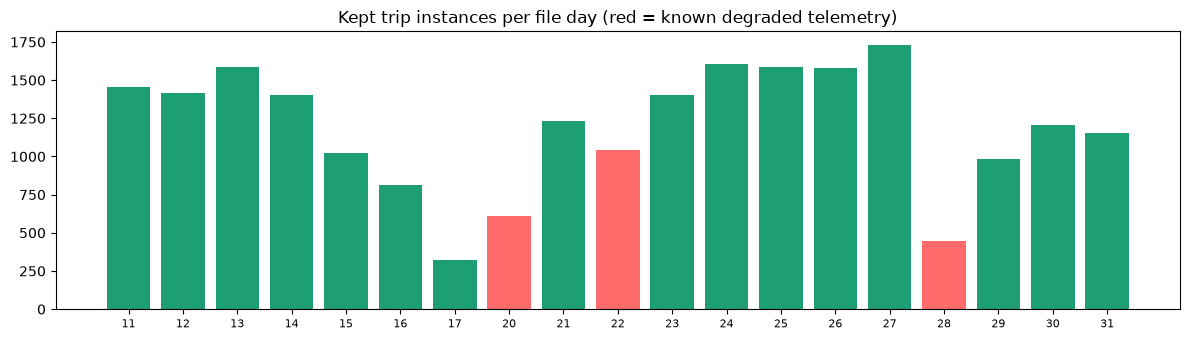

file_date
2026-03-11    1454
2026-03-12    1419
2026-03-13    1584
2026-03-14    1401
2026-03-15    1021
2026-03-16     816
2026-03-17     319
2026-03-20     612
2026-03-21    1233
2026-03-22    1045
2026-03-23    1405
2026-03-24    1606
2026-03-25    1588
2026-03-26    1579
2026-03-27    1733
2026-03-28     449
2026-03-29     984
2026-03-30    1204
2026-03-31    1153


In [7]:
per_day = meta.groupby("file_date").size()
colors = ["#FF6B6B" if dstr in prep.DEGRADED_DAYS else "#1D9E75"
          for dstr in per_day.index]
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.bar(range(len(per_day)), per_day.values, color=colors)
ax.set_xticks(range(len(per_day)))
ax.set_xticklabels([s[8:] for s in per_day.index], fontsize=8)
ax.set_title("Kept trip instances per file day (red = known degraded telemetry)")
plt.tight_layout(); plt.savefig(os.path.join(prep.CACHE_DIR, "verify_per_day.png"), dpi=120)
plt.show()
print(per_day.to_string())

## 6. Verification — map-matching sanity (one random trip)

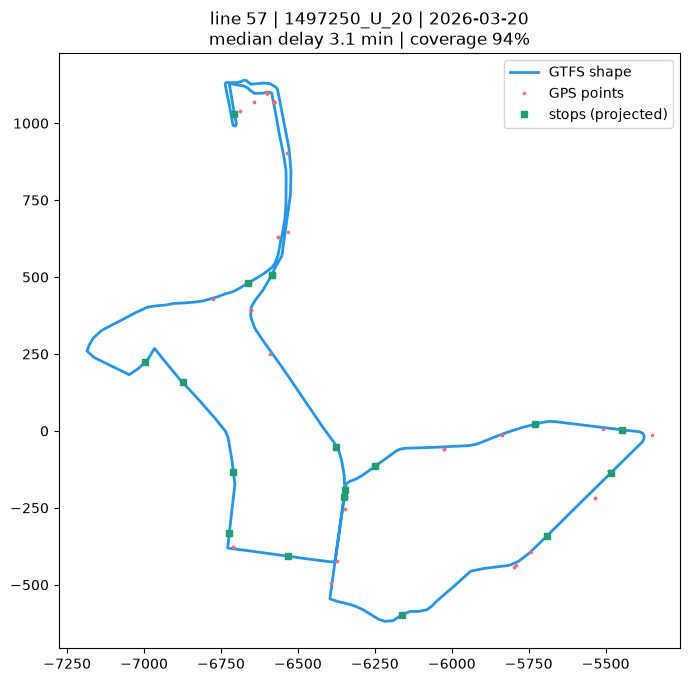

In [8]:
rng = np.random.default_rng(0)
row = meta.sample(1, random_state=7).iloc[0]
day_csv = os.path.join(prep.MOBILITY_DIR, f"{row.file_date}.csv")
raw = pd.read_csv(day_csv)
raw = raw[(raw["tripId"] == row.trip_id) & (raw["id"] == row.vehicle)]
sched = prep.lookup_sched(gtfs_index, row.trip_id, row.file_date, int(row.direction))
pts = prep.to_local_xy(raw["lat"].to_numpy(), raw["lng"].to_numpy())

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(sched.shape_xy[:, 0], sched.shape_xy[:, 1], "-", color="#2196F3",
        lw=2, label="GTFS shape")
ax.plot(pts[:, 0], pts[:, 1], ".", color="#FF6B6B", ms=3, label="GPS points")
stop_xy_along = np.column_stack([
    np.interp(sched.stop_dist, sched.cum_len, sched.shape_xy[:, 0]),
    np.interp(sched.stop_dist, sched.cum_len, sched.shape_xy[:, 1])])
ax.plot(stop_xy_along[:, 0], stop_xy_along[:, 1], "s", color="#1D9E75",
        ms=5, label="stops (projected)")
ax.set_title(f"line {row.line_id} | {row.trip_id} | {row.file_date}\n"
             f"median delay {row.median_delay_sec/60:.1f} min | "
             f"coverage {row.stop_coverage:.0%}")
ax.legend(); ax.set_aspect("equal")
plt.tight_layout(); plt.savefig(os.path.join(prep.CACHE_DIR, "verify_mapmatch.png"), dpi=120)
plt.show()

## 7. Final cache summary

In [9]:
z = np.load(os.path.join(prep.CACHE_DIR, "sequences.npz"), allow_pickle=True)
X, lengths, y = z["X"], z["lengths"], z["y"]
print("X:", X.shape, X.dtype, "| lengths:", lengths.min(), "-", lengths.max(),
      "| positives:", f"{y.mean():.1%}")
print("days:", len(np.unique(z["groups"])))
print("\nper-feature ranges (unscaled):")
for i, c in enumerate(prep.FEATURE_COLS):
    col = X[:, :, i]
    print(f"  {c:15s} min {col.min():10.2f}  max {col.max():10.2f}  "
          f"mean {col.mean():8.3f}")
print("\nfeature NaN check:", np.isnan(X).sum(), "NaNs (must be 0)")
assert np.isnan(X).sum() == 0
print("\nCache complete:", sorted(os.listdir(prep.CACHE_DIR)))

X: (22605, 64, 12) float32 | lengths: 9 - 64 | positives: 20.9%
days: 20

per-feature ranges (unscaled):
  speed_mps       min       0.00  max     174.18  mean    2.764
  accel           min    -174.18  max     174.18  mean   -0.082
  heading_change  min       0.00  max     180.00  mean    7.362
  progress_frac   min       0.00  max       1.00  mean    0.612
  progress_rate   min       0.00  max       0.96  mean    0.014
  cross_track_m   min       0.00  max     200.00  mean   14.894
  dwell_frac      min       0.00  max       1.00  mean    0.706
  tod_sin         min      -1.00  max       1.00  mean   -0.057
  tod_cos         min      -1.00  max       1.00  mean   -0.292
  is_weekend      min       0.00  max       1.00  mean    0.254
  rain_mm         min       0.00  max      11.80  mean    0.104
  headway_min     min       0.00  max      60.00  mean   25.787

feature NaN check: 0 NaNs (must be 0)

Cache complete: ['gtfs_index.pkl', 'preprocess_counters.csv', 'sequences.npz', 'trips_m